In [1]:
from pathlib import Path
import sys

parent_dir = '..'
sys.path.append(parent_dir)

In [2]:
from utils import plot_silhouette

In [3]:
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from seaborn import axes_style
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

In [4]:
import pycatch22
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sktime.transformations.series.adapt import TabularToSeriesAdaptor

In [5]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
theme_dict = {**axes_style('whitegrid'), 'context': 'notebook', 'palette': 'muted'}
so.Plot.config.theme.update(theme_dict)

In [6]:
data_dir = Path('../../results')

In [7]:
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
# Make rating category ordinal
train['rating_category'] = pd.Categorical(train['rating_category'],
               categories=['Low', 'Medium Low', 'Medium', 'Medium High', 'High'],
               ordered=True)
train.shape

(850, 113)

In [8]:
train_X = train[[str(i) for i in range(100)]]
train_X = train_X.reset_index().melt(id_vars='id', var_name='time')
train_X['time'] = train_X['time'].astype('int')
train_X = train_X.set_index(['id', 'time'])
train_X

,,value
id,time,
tt10855768,0,3433703.0
tt3766354,0,13375850.0
tt6791096,0,6199651.0
tt1821549,0,35536.0
tt7144666,0,10241355.0
...,...,...
tt7668870,99,26209.0
tt8884430,99,36465.0
tt9883996,99,2417.0


## Catch 22 features

sktime catch22 transformer has some problems I have no time to debug, nor do I want to downgrade sktime version at the moment, so we are doing it manually.

We extract catch22 features plus mean and standard deviation.

In [9]:
result = pycatch22.catch22_all(train_X.loc[train.index[0]].values, catch24=True, short_names=True)
columns = result['short_names']

In [10]:
%%time
data = []
for idx in train.index:
    values = pycatch22.catch22_all(train_X.loc[idx].values, catch24=True)['values']
    data.append(values)
train_c22 = pd.DataFrame(data, columns=columns)
train_c22.index = train.index

CPU times: user 2.74 s, sys: 5.18 ms, total: 2.75 s
Wall time: 2.75 s


In [11]:
train_c22.head()

,mode_5,mode_10,acf_timescale,acf_first_min,ami2,trev,high_fluctuation,stretch_high,transition_matrix,periodicity,...,outlier_timing_neg,centroid_freq,stretch_decreasing,entropy_pairs,rs_range,dfa,low_freq_power,forecast_error,mean,SD
id,,,,,,,,,,,,,,,,,,,,,
tt10855768,-0.333098,-0.569656,3.292878,9,0.231946,-0.049935,0.767677,8.0,0.062500,13,...,0.550,0.817875,12.0,1.717638,0.314286,0.314286,0.392699,0.585646,640039.02,7.741079e+05
tt3766354,-0.204680,-0.447203,5.038619,10,0.384456,-0.035084,0.676768,20.0,0.074074,13,...,0.480,0.855605,10.0,1.544890,0.171429,0.600000,0.147262,0.370692,1975049.87,2.740085e+06
tt6791096,-0.235415,-0.476199,4.240450,9,0.381551,-0.037754,0.535354,20.0,0.074074,13,...,0.475,0.845503,12.0,1.499035,0.171429,0.600000,0.196350,0.443455,947198.80,1.281488e+06
tt1821549,-0.968873,-0.759462,3.452775,8,0.382275,0.029799,0.787879,18.0,0.002604,14,...,-0.550,0.877449,7.0,1.670886,0.828571,0.742857,0.392699,0.713396,131952.38,8.647096e+04
tt7144666,-0.305268,-0.580867,5.878877,9,0.412512,-0.022879,0.676768,25.0,0.074074,14,...,0.555,0.843426,6.0,1.452820,0.171429,0.600000,0.098175,0.338991,1710723.00,1.832369e+06


In [12]:
train_c22.info()

<class 'pandas.core.frame.DataFrame'>
Index: 850 entries, tt10855768 to tt9620292
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mode_5              850 non-null    float64
 1   mode_10             850 non-null    float64
 2   acf_timescale       850 non-null    float64
 3   acf_first_min       850 non-null    int64  
 4   ami2                850 non-null    float64
 5   trev                850 non-null    float64
 6   high_fluctuation    850 non-null    float64
 7   stretch_high        850 non-null    float64
 8   transition_matrix   850 non-null    float64
 9   periodicity         850 non-null    int64  
 10  embedding_dist      850 non-null    float64
 11  ami_timescale       850 non-null    float64
 12  whiten_timescale    850 non-null    float64
 13  outlier_timing_pos  850 non-null    float64
 14  outlier_timing_neg  850 non-null    float64
 15  centroid_freq       850 non-null    float64
 16

### Analysis of some features

As we saw during data understanding, almost all time series of our dataset have periodicity around two weeks.

<Axes: ylabel='Frequency'>

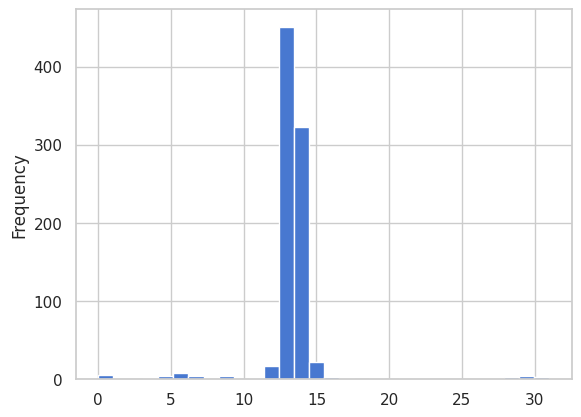

In [13]:
train_c22['periodicity'].plot.hist(bins=30)

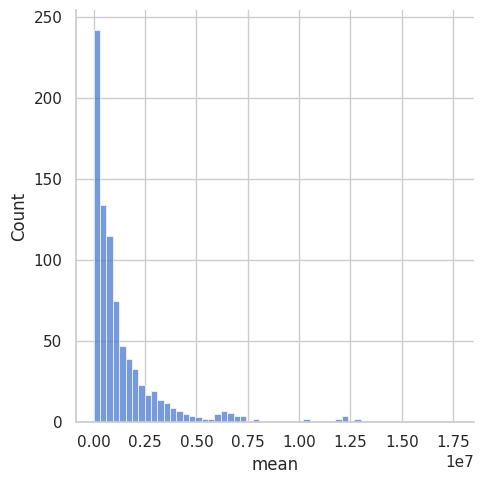

In [14]:
sns.displot(train_c22, x='mean')

In [15]:
train_c22['mean'].describe()

count    8.500000e+02
mean     1.484220e+06
std      2.189652e+06
min      1.397770e+03
25%      2.540882e+05
50%      7.521191e+05
75%      1.724224e+06
max      1.763034e+07
Name: mean, dtype: float64

In [16]:
train[train_c22['mean'] < 10000]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt11614912,She Dies Tomorrow,2020,86,7685,['US'],True,0.0,8.0,5.0,"['Drama', 'Fantasy', 'Horror']",...,1134.0,1361.0,2573.0,4119.0,5030.0,5805.0,3465.0,1547.0,1007.0,636.0
tt5738280,Dutch,2021,109,654,['US'],False,0.0,0.0,4.2,['Action'],...,1981.0,2259.0,1476.0,861.0,897.0,933.0,911.0,889.0,1022.0,1181.0
tt0064816,The Swimming Pool,1969,122,15502,"['FR', 'IT']",False,0.0,0.0,7.1,"['Crime', 'Drama', 'Romance']",...,1995.0,1972.0,1251.0,637.0,734.0,857.0,785.0,724.0,713.0,699.0
tt8477134,Tulsa,2020,120,1277,['US'],True,1.0,2.0,6.3,"['Comedy', 'Drama']",...,7681.0,5680.0,3972.0,1805.0,3111.0,4151.0,3003.0,2107.0,2179.0,2253.0
tt13327144,The Forgotten Carols,2020,130,85,['US'],False,0.0,0.0,8.4,['Musical'],...,277.0,232.0,163.0,122.0,165.0,209.0,145.0,105.0,115.0,128.0
tt11169050,Supernova,2020,95,15702,['GB'],True,3.0,10.0,6.9,"['Drama', 'Romance']",...,494.0,414.0,235.0,45.0,38.0,31.0,85.0,135.0,148.0,164.0
tt5577494,Clemency,2019,112,5714,['US'],True,4.0,32.0,6.5,['Drama'],...,3986.0,3159.0,2388.0,1576.0,1666.0,1732.0,1553.0,1388.0,1682.0,1920.0
tt10195452,American Skin,2019,90,4111,"['IT', 'US']",True,1.0,5.0,7.0,"['Drama', 'Thriller']",...,5985.0,4009.0,3022.0,1708.0,1528.0,1328.0,1623.0,1930.0,1928.0,1927.0
tt12971924,The Call,2020,97,5555,"['US', 'CA']",False,0.0,0.0,4.2,"['Horror', 'Mystery', 'Thriller']",...,126.0,104.0,140.0,175.0,121.0,80.0,92.0,105.0,100.0,95.0


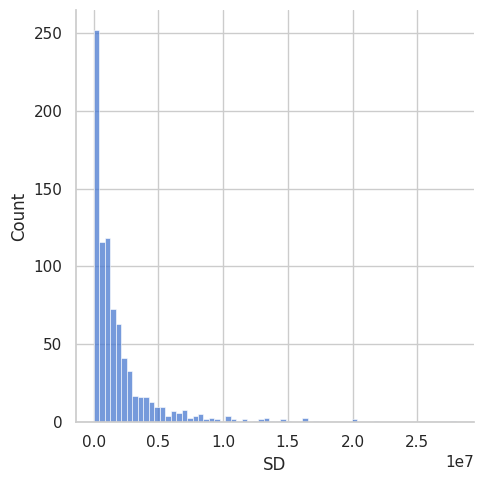

In [17]:
sns.displot(train_c22, x='SD')

Mean and standard deviation are highly linearly correlated.

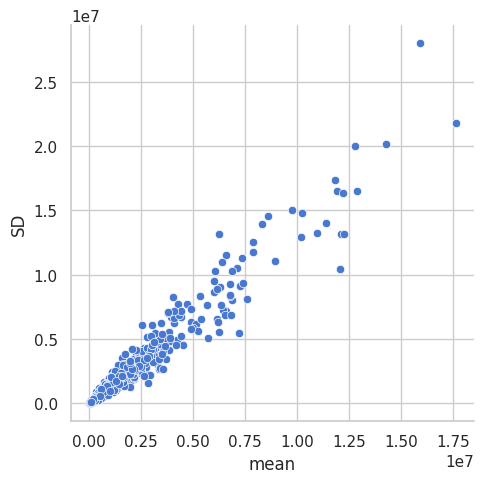

In [18]:
sns.relplot(train_c22, x='mean', y='SD')

## Clustering

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np

In [20]:
def get_linkage_matrix(model):
    # Create linkage matrix

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

### Hierarchical clustering

We inspected the dendrograms for different linkage strategies: the most promising one was ward.

In [21]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('hier_clust', AgglomerativeClustering(
        n_clusters=None, distance_threshold=0, linkage='ward'
    ))
])

In [22]:
%%time
pipeline.fit(train_c22)

CPU times: user 17.1 ms, sys: 2.08 ms, total: 19.2 ms
Wall time: 18.3 ms


,steps,"[('scaler', ...), ('hier_clust', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,None
,metric,'euclidean'
,memory,None
,connectivity,None


In [23]:
threshold = 45

([], [])

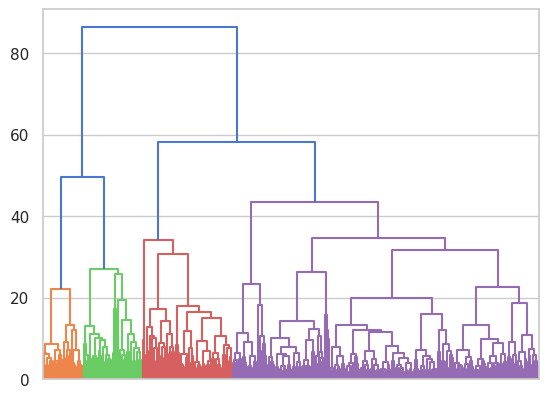

In [24]:
hier_clust = pipeline[-1]
plot_dendrogram(hier_clust, color_threshold=threshold)
plt.xticks([], [])

In [25]:
linkage_matrix = get_linkage_matrix(hier_clust)
labels = fcluster(linkage_matrix, criterion='distance', t=threshold)

In [26]:
np.unique(labels, return_counts=True)

(array([1, 2, 3, 4], dtype=int32), array([ 70, 101, 155, 524]))

In [27]:
print("Silhouette score:", silhouette_score(pipeline[:-1].transform(train_c22), labels=labels))

Silhouette score: 0.21275171235105664


In [28]:
scaler = TabularToSeriesAdaptor(StandardScaler())
train_X_norm = scaler.fit_transform(train_X)

In [29]:
train['hier'] = pd.Categorical(labels)
train_X_norm['hier'] = train_X_norm.index.get_level_values(0).map(train['hier'])

In [30]:
def get_medoids(dist_matrix, labels):
    medoids = []
    dist_matrix_df = pd.DataFrame(dist_matrix, index=train.index.get_level_values(0), columns=train.index.get_level_values(0))
    grouped = dist_matrix_df.groupby(labels)
    for _, group in grouped:
        medoids.append(group[group.index].sum(axis=0).idxmin())
    return medoids

In [31]:
dist_matrix = distance_matrix(pipeline[:-1].transform(train_c22), pipeline[:-1].transform(train_c22))
dist_matrix.shape
medoids = get_medoids(dist_matrix, labels)
movies = list(train.loc[medoids, 'title'])
medoids

['tt2024544', 'tt1798709', 'tt3416828', 'tt1179933']

In [32]:
def get_plot_title(idx):
    idx = int(idx)
    df = train.loc[medoids].set_index('hier')
    return f"Cluster {idx}\n" + df.loc[idx, 'title'] + ' ' + str(df.loc[idx, 'startYear'])

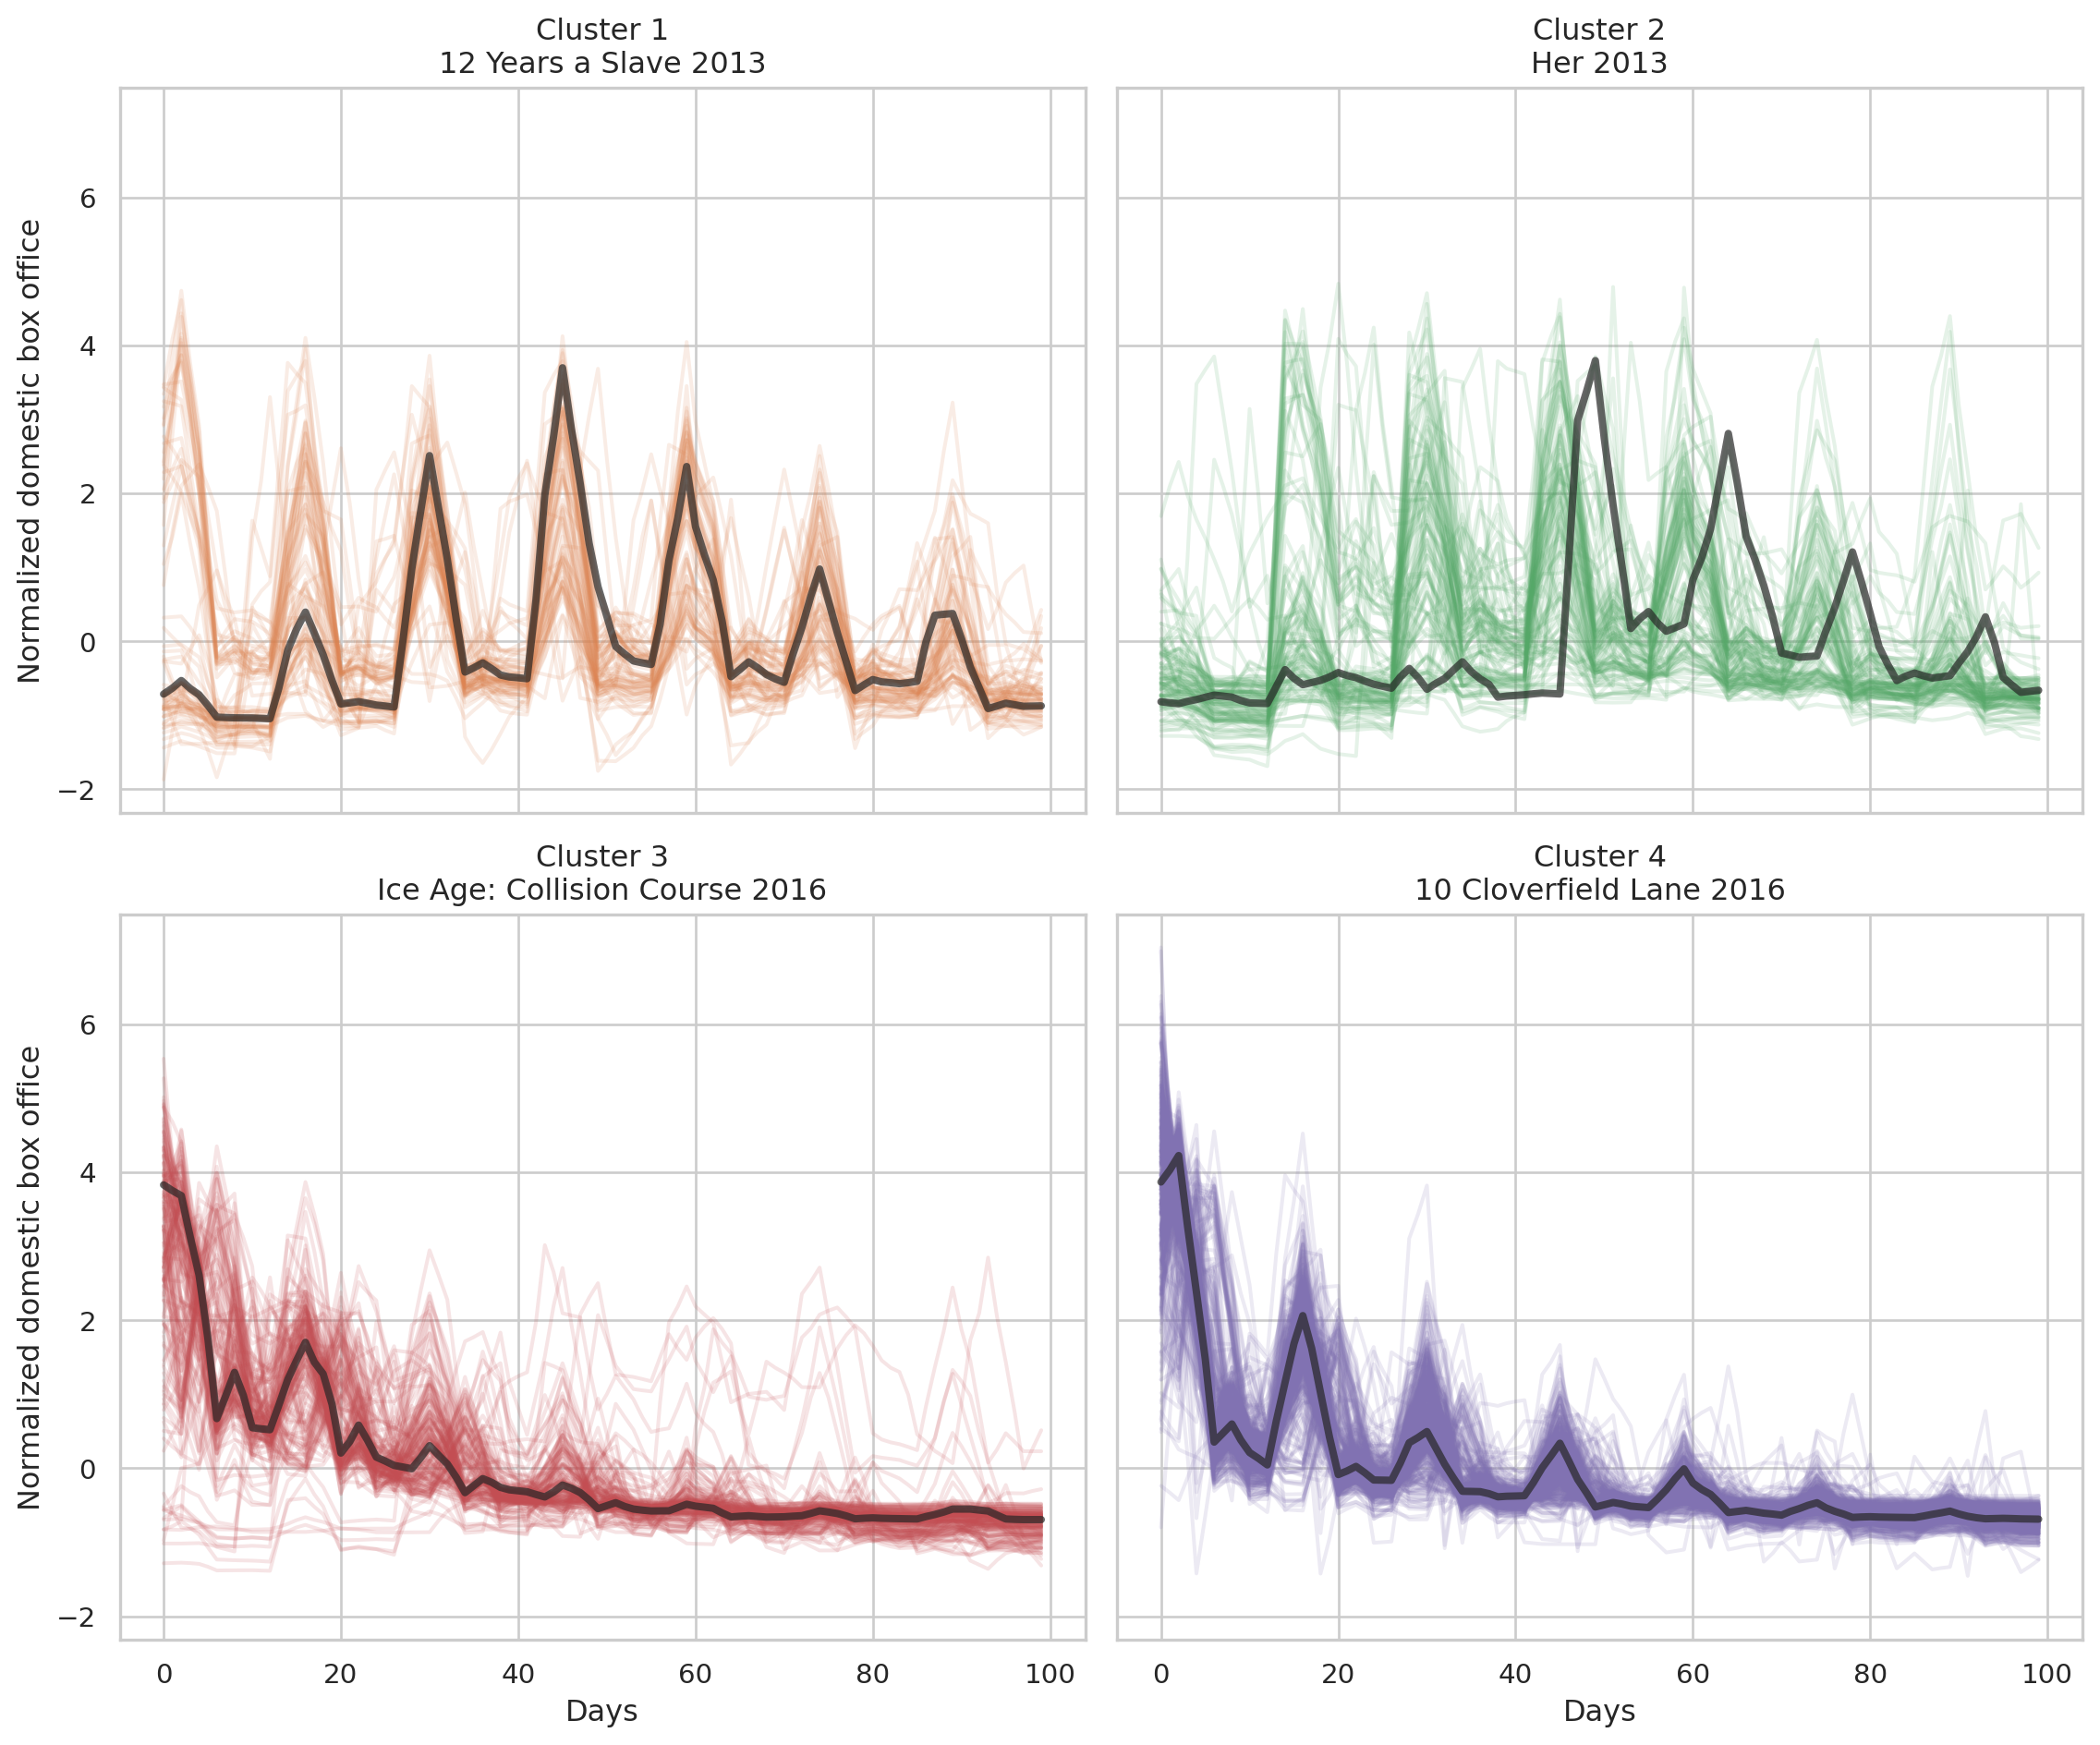

In [33]:
(
    so.Plot(train_X_norm, x='time', y='value')
    .facet(col='hier', wrap=2)
    .add(so.Lines(alpha=.15), group='id', color='hier', legend=False)
    .add(so.Lines(linewidth=3, color='k', alpha=.7), data=train_X_norm.loc[medoids])

    # Use the same colors as the dendrogram
    .scale(color=so.Nominal(('C1', 'C2', 'C3', 'C4', 'C5'), order=(1, 2, 3, 4, 5)))
    .label(x='Days', y='Normalized domestic box office', title=get_plot_title)
    .layout(size=(12, 10))
)

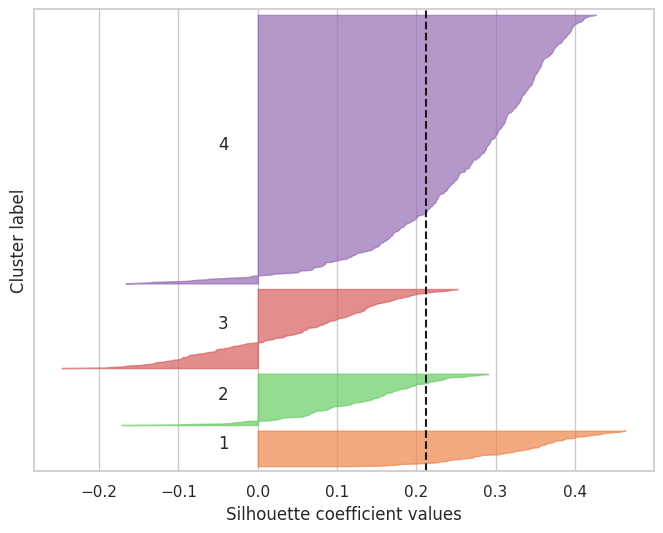

In [34]:
fig, ax = plt.subplots()
fig.set_size_inches((8, 6))
plot_silhouette(pipeline[:-1].transform(train_c22), cluster_labels=labels, ax=ax)

### Analysis of clusters

In [35]:
train_c22.groupby(train['hier'])['mean'].describe()

/tmp/ipykernel_18212/496684536.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_c22.groupby(train['hier'])['mean'].describe()


,count,mean,std,min,25%,50%,75%,max
hier,,,,,,,,
1,70.0,5.948588e+05,1.101344e+06,1397.77,74206.6875,180677.305,4.899804e+05,6224584.65
2,101.0,4.456218e+05,8.054596e+05,7194.07,91370.4900,217212.480,4.184572e+05,6012736.46
3,155.0,1.012257e+06,1.310372e+06,5441.44,194636.3150,556222.990,1.212101e+06,7191192.43
4,524.0,1.942824e+06,2.530331e+06,4526.73,511753.1175,1046290.560,2.174401e+06,17630342.74


<Axes: xlabel='mean', ylabel='Density'>

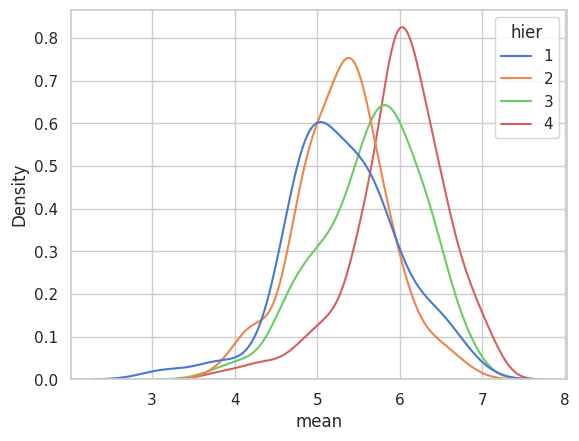

In [36]:
sns.kdeplot(x=np.log10(train_c22['mean']), hue=train['hier'], common_norm=False)

Movies from cluster 1 and 2 have on average lower mean box-office (median in the 100k, while for cluster 3 median is in the millions) in the 100 days window. It would be interesting if a similar patter emerges also in shape-based clustering (which doesn't know anything about the level of the timeseries, since they were normalized before computing distances).

In [37]:
pd.concat([train, train_c22], axis=1).loc[medoids, ['title', 'mean', 'SD', 'hier', 'awards', 'nominations', 'rating', 'rating_category']]

,title,mean,SD,hier,awards,nominations,rating,rating_category
id,,,,,,,,
tt2024544,12 Years a Slave,693576.05,5.918059e+05,1,244.0,338.0,8.1,High
tt1798709,Her,442614.27,4.730122e+05,2,83.0,187.0,8.0,High
tt3416828,Ice Age: Collision Course,1232276.45,1.753778e+06,3,2.0,0.0,5.7,Medium
tt1179933,10 Cloverfield Lane,1392476.78,1.970527e+06,4,16.0,48.0,7.2,High


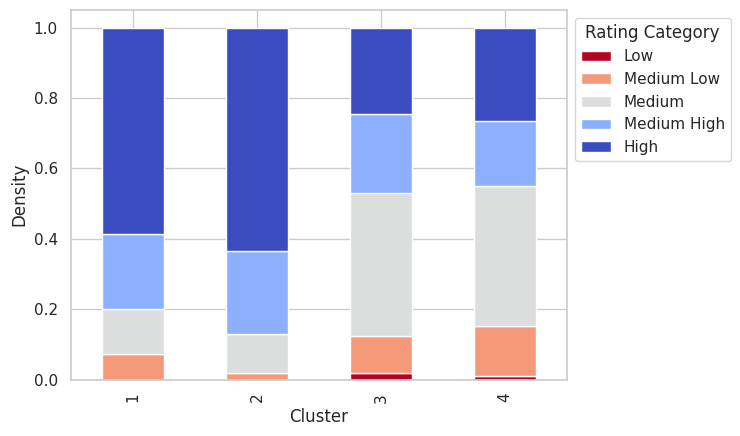

In [38]:
clustering = 'hier'
pd.crosstab(train[clustering], train['rating_category'], normalize='index').plot.bar(stacked=True, colormap='coolwarm_r')
plt.xlabel('Cluster')
plt.ylabel('Density')
plt.legend(title='Rating Category', bbox_to_anchor=(1, 1))

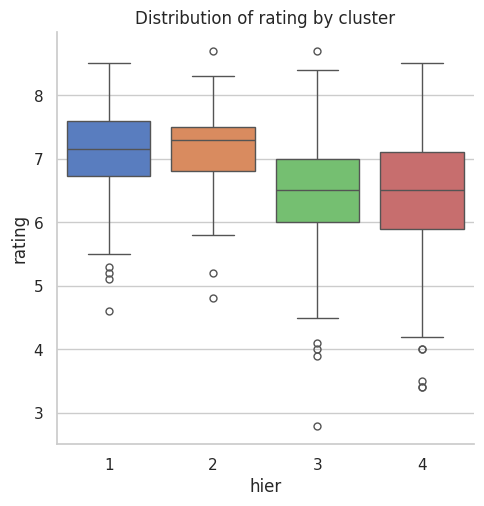

In [39]:
sns.catplot(train, x=clustering, y='rating', kind='box', hue=clustering, legend=False)
plt.title("Distribution of rating by cluster")
plt.show()

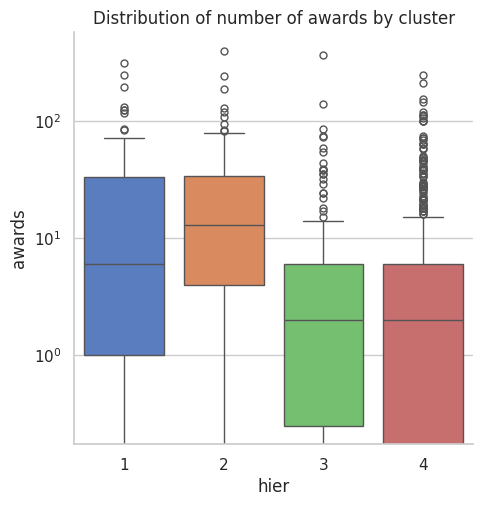

In [40]:
sns.catplot(train, x=clustering, y='awards', kind='box', hue=clustering, legend=False)
plt.title("Distribution of number of awards by cluster")
plt.yscale('log')
plt.show()

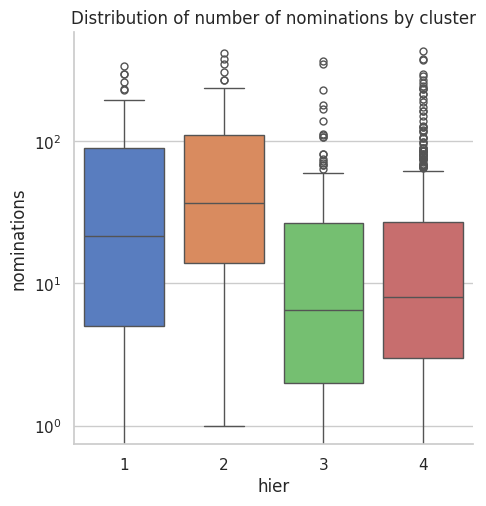

In [41]:
sns.catplot(train, x=clustering, y='nominations', kind='box', hue=clustering, legend=False)
plt.title("Distribution of number of nominations by cluster")
plt.yscale('log')
plt.show()

<Axes: xlabel='hier'>

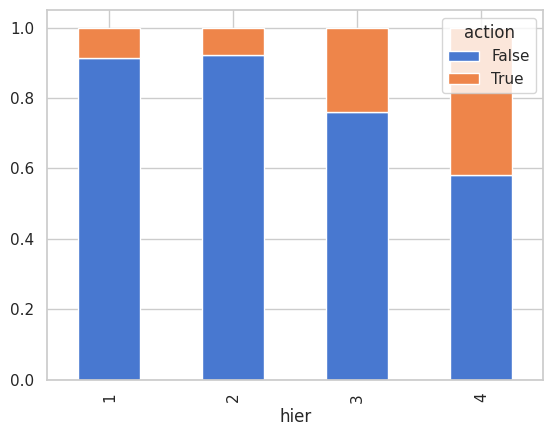

In [42]:
train['action'] = train['genre'].map(lambda x: 'Action' in x)
action_by_clust = pd.crosstab(train[clustering], train['action'], normalize='index')
action_by_clust.plot.bar(stacked='True')

<Axes: xlabel='hier'>

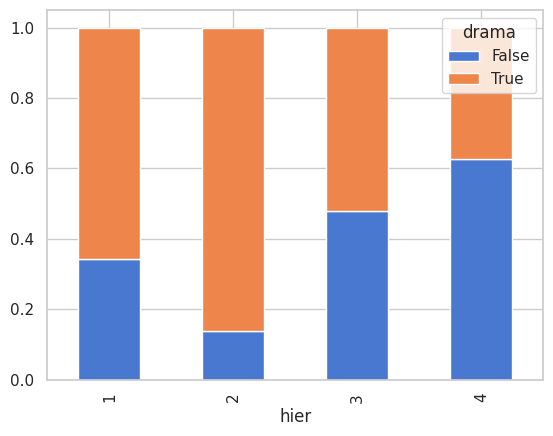

In [43]:
train['drama'] = train['genre'].map(lambda x: 'Drama' in x)
drama_by_clust = pd.crosstab(train[clustering], train['drama'], normalize='index')
drama_by_clust.plot.bar(stacked='True')

<Axes: xlabel='hier'>

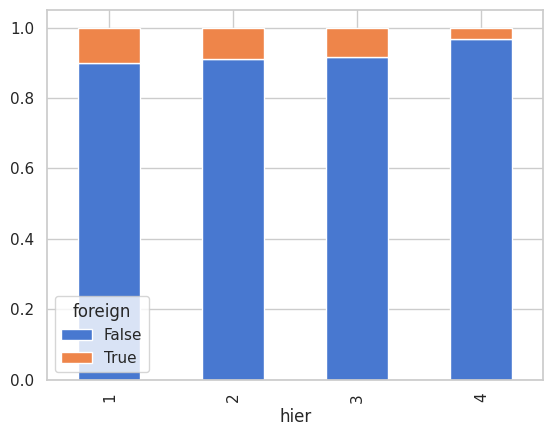

In [44]:
train['foreign'] = train['countryOfOrigin'].apply(lambda x: 'US' not in x)
pd.crosstab(train[clustering], train['foreign'], normalize='index').plot.bar(stacked=True)

<Axes: xlabel='hier'>

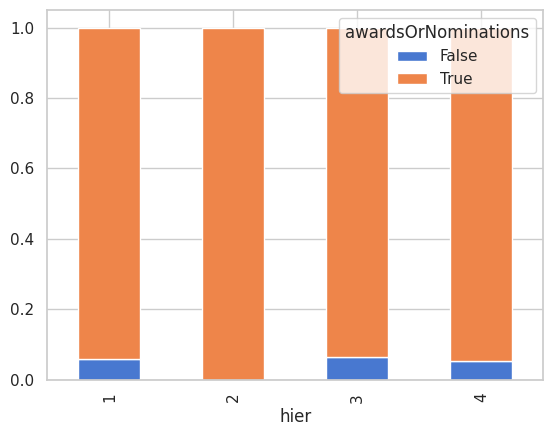

In [45]:
pd.crosstab(train[clustering], train['awardsOrNominations'], normalize='index').plot.bar(stacked='True')

Similar patterns to those observed in shape based clustering with respect to rating, rating category, awards, nominations, distributiion of action movies and distribution of dramatic movies.

## Dimensionality reduction

In [46]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

### PCA

In [47]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42))
])

pca_train = pca_pipeline.fit_transform(train_c22)
pca_train = pd.DataFrame(pca_train)
pca_train.index = train.index

In [48]:
explained_variance = pca_pipeline[-1].explained_variance_ratio_

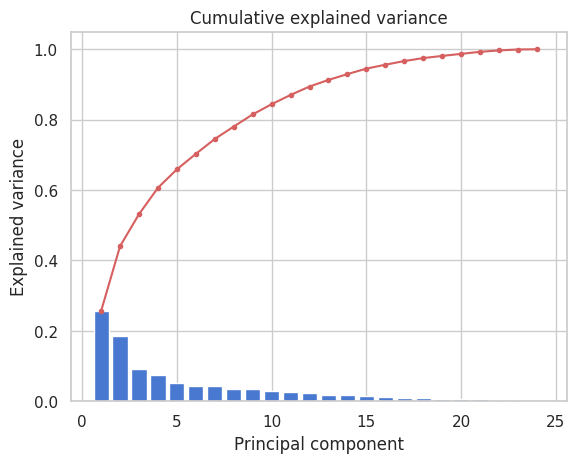

In [49]:
x = list(range(1, len(explained_variance) + 1))
plt.bar(x, height=explained_variance)
plt.plot(x, explained_variance.cumsum(), 'r.-')
plt.xlabel("Principal component")
plt.ylabel("Explained variance")
plt.title("Cumulative explained variance")
plt.show()

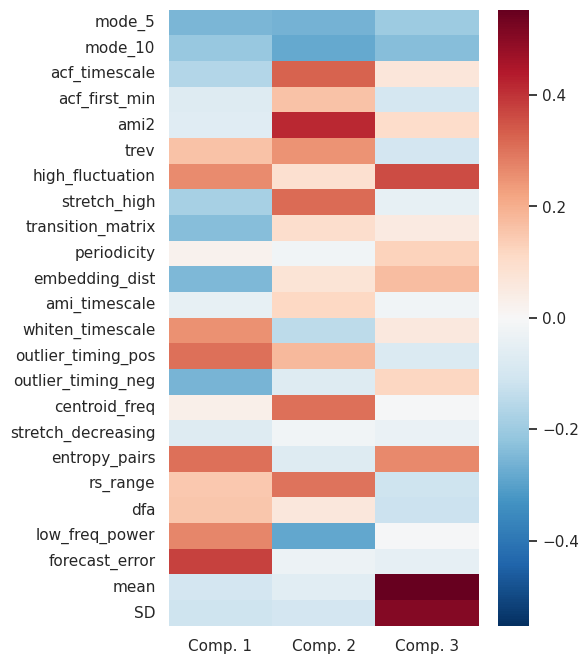

In [50]:
n_comp = 3

components = pca_pipeline[-1].components_[:n_comp].T
vmax = np.abs(components).max()

plt.figure(figsize=(2+n_comp, 8))
sns.heatmap(components, cmap='RdBu_r', vmax=vmax, vmin=-vmax)
plt.xticks(np.arange(n_comp) + .5, labels=[f'Comp. {i+1}' for i in range(n_comp)])
plt.yticks(ticks=np.arange(len(columns)) + .5, labels=columns, rotation=0)
plt.show()

In [51]:
cluster_palette = [f'C{i}'
                   for i in range(1, 5)]

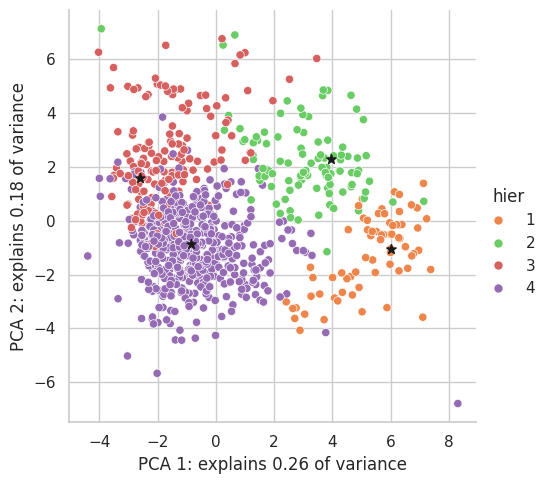

In [52]:
x, y = 0, 1
g = sns.relplot(pca_train, x=x, y=y, hue=train['hier'], palette=cluster_palette)
plt.xlabel(f"PCA {x+1}: explains {round(explained_variance[x], 2)} of variance")
plt.ylabel(f"PCA {y+1}: explains {round(explained_variance[y], 2)} of variance")
plt.scatter(x=pca_train.loc[medoids][x], y=pca_train.loc[medoids][y], c='k', marker='*', s=50)


### TSNE

In [53]:
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(perplexity=25, random_state=42))
])

tsne_train = pd.DataFrame(tsne_pipeline.fit_transform(train_c22))
tsne_train.index = train.index

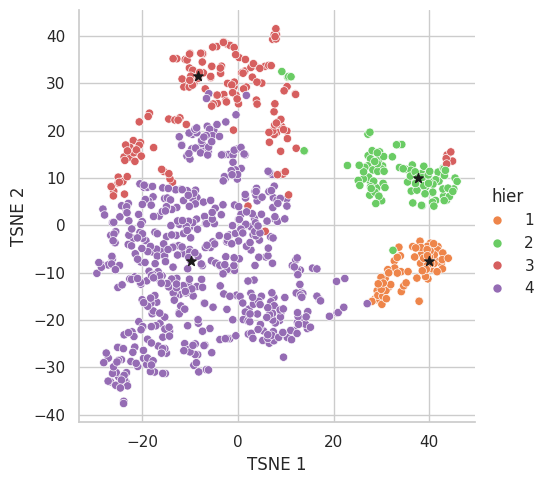

In [54]:
sns.relplot(tsne_train, x=x, y=y, hue=train['hier'], palette=cluster_palette)
plt.xlabel(f"TSNE {x+1}")
plt.ylabel(f"TSNE {y+1}")
plt.scatter(x=tsne_train.loc[medoids][x], y=tsne_train.loc[medoids][y], c='k', marker='*', s=50)